# Charge-per-cycle & actuation efficiency: PPy-in-tissue vs pure PPy film

**Question (per CP-actuator diagnostic):** integrate the current over the *last* CV cycle to get
charge passed, normalize to construct area/volume, and compare against the thin-film baseline.

> *Low charge density -> electrical access problem (percolation/loading).
> Healthy charge but bad strain -> downstream problem (diffusion or coupling).
> Strain(force)-per-charge is the canonical CP-actuator efficiency metric.*

**Samples (both FORCE / isometric, 1x gain = 56.7 mN/V, last cycle integrated):**
- **TISSUE** = PPy electropolymerized in decell chicken tissue. `05.22.26-neg25C_in_tissue_FORCE`, 3 mV/s, 2 cycles. Cross-section 3.0 x 1.467 mm.
- **FILM** = pure distilled-pyrrole PPy thin film (thin-film baseline). `06.03.26-neg25C_distilledpyrrole_FORC`, 2.5 mV/s, 3 cycles. Cross-section 3.0 x 0.028 mm.
- Actuation axis L0 = 4 mm (from the paired LENGTH notebooks) assumed for both -> volume = w x t x L0.

We also (a) split the charge into ohmic-leakage vs non-ohmic (capacitive+faradaic), and
(b) test whether the force swing is *coherent with the applied potential* (real actuation) or just drift.

In [1]:
import io, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

GAIN_MN_PER_V = 56.7          # force-sensor, 1x
L0_MM = 4.0                   # actuation axis (from LENGTH notebooks)

SAMPLES = {
 'TISSUE 05.22 (PPy in decell)': dict(
    poten='Potentiostat_measurements/05.22.26-neg25C_in_tissue_FORCE_3mVpersec.csv',
    scope='scope_log_20260522_160605_successful_-25C_PPy_electrochem_in_tissue_1chempol_-25C_buffered_FORCE.csv',
    scan_rate=0.003, width_mm=3.0, thick_mm=1.467),
 'TISSUE 06.15 (2-day decell)': dict(
    poten='Potentiostat_measurements/06.15.26-2Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
    scope='scope_log_20260615_134504_2Day_10%_formalin_2.5mVperSecond_FORCE.csv',
    scan_rate=0.0025, width_mm=2.5, thick_mm=0.45),
 'FILM (pure PPy)': dict(
    poten='Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_FORC_2.5mVpersec.csv',
    scope='scope_log_20260603_141224_distilled_pyrrole_neg25C_synthesis_2.5mVperSec.csv',
    scan_rate=0.0025, width_mm=3.0, thick_mm=0.028),
}

def load_poten(path):
    with open(path,'rb') as f: text=f.read().decode('utf-16').replace('﻿','')
    rows=[r for r in csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))) if r and r[0]]
    n=len(rows[0])//2
    cols=[]; [cols.extend([f'v{s+1}', f'i{s+1}_uA']) for s in range(n)]
    return pd.DataFrame([[float(x) for x in r[:2*n]] for r in rows], columns=cols), n

def derive_dt(poten, sr):
    v1=poten['v1'].values; turn=int(np.argmin(v1))
    return abs(v1[0]-v1[turn])/turn/sr

In [2]:
# ---- Integrate charge over the LAST cycle + split ohmic vs non-ohmic; get coherent force swing ----
def analyze(s):
    poten, n = load_poten(s['poten'])
    dt = derive_dt(poten, s['scan_rate']); per = len(poten)*dt
    v = poten[f'v{n}'].values; i_uA = poten[f'i{n}_uA'].values   # last cycle
    i_A = i_uA*1e-6; t = np.arange(len(i_A))*dt

    q_anodic   = np.trapezoid(np.clip(i_A,0,None), t)*1e3        # mC
    q_cathodic = np.trapezoid(np.clip(-i_A,0,None), t)*1e3
    q_mean = 0.5*(q_anodic+q_cathodic)

    # ohmic backbone: least-squares i = V/R + b ; residual = capacitive+faradaic
    A=np.vstack([v,np.ones_like(v)]).T
    slope,inter = np.linalg.lstsq(A,i_uA,rcond=None)[0]; pred=A@np.array([slope,inter])
    r2 = 1-np.sum((i_uA-pred)**2)/np.sum((i_uA-i_uA.mean())**2)
    q_ohmic   = np.trapezoid(np.abs(pred*1e-6), t)*1e3
    q_nonohm  = np.trapezoid(np.abs((i_uA-pred)*1e-6), t)*1e3
    R_ohm = 1.0/(slope*1e-6)
    frac_nonohm = q_nonohm/(q_ohmic+q_nonohm)

    # force swing over last cycle + coherence with applied potential
    sc=pd.read_csv(s['scope']); sc_t=sc['elapsed_s'].values
    t_full=np.concatenate([np.arange(len(poten))*dt+k*per for k in range(n)])
    v_full=np.concatenate([poten[f'v{k+1}'].values for k in range(n)])
    m=(sc_t>=(n-1)*per)&(sc_t<n*per); ys_t=sc_t[m]; y=sc['ch2_MEAN_V'].values[m]
    order=np.argsort(ys_t); ys_t=ys_t[order]; y=y[order]
    w=min(151,len(y)); w=w-1 if w%2==0 else w; ysm=savgol_filter(y,w,3)
    vapp=np.interp(ys_t,t_full,v_full)
    swing_V=ysm.max()-ysm.min()
    force_pp=swing_V*GAIN_MN_PER_V
    coherence=np.corrcoef(ysm,vapp)[0,1]

    area=s['width_mm']*s['thick_mm']; vol=area*L0_MM
    return dict(n_cycles=n, dt=dt, cycle_s=per, R_ohm=R_ohm, r2_ohmic=r2,
        i_peak_uA=np.abs(i_uA).max(), q_anodic_mC=q_anodic, q_cathodic_mC=q_cathodic,
        q_mean_mC=q_mean, q_ohmic_mC=q_ohmic, q_nonohmic_mC=q_nonohm, frac_nonohmic=frac_nonohm,
        area_mm2=area, vol_mm3=vol,
        q_per_area_mC_cm2=q_mean/(area*1e-2), q_per_vol_mC_cm3=q_mean/(vol*1e-3),
        qNON_per_vol_mC_cm3=(q_nonohm/2)/(vol*1e-3),
        force_pp_mN=force_pp, stress_pp_kPa=force_pp/area, coherence_force_V=coherence,
        force_per_charge_mN_mC=force_pp/q_mean,
        force_per_nonohmCharge=force_pp/(q_nonohm/2),
        v=v, i_uA=i_uA, pred=pred, ysm=ysm, vapp=vapp)

res={name:analyze(s) for name,s in SAMPLES.items()}
keys=['n_cycles','cycle_s','i_peak_uA','R_ohm','r2_ohmic',
      'q_anodic_mC','q_cathodic_mC','q_mean_mC','q_ohmic_mC','q_nonohmic_mC','frac_nonohmic',
      'area_mm2','vol_mm3','q_per_area_mC_cm2','q_per_vol_mC_cm3','qNON_per_vol_mC_cm3',
      'force_pp_mN','stress_pp_kPa','coherence_force_V','force_per_charge_mN_mC','force_per_nonohmCharge']
tbl=pd.DataFrame({nm:{k:res[nm][k] for k in keys} for nm in res})
pd.set_option('display.float_format', lambda x:f'{x:,.4g}')
tbl

,TISSUE 05.22 (PPy in decell),TISSUE 06.15 (2-day decell),FILM (pure PPy)
n_cycles,2,3,3
cycle_s,"1,334","1,600","1,600"
i_peak_uA,"3,483","2,242",891.4
R_ohm,422,637.2,"2,419"
r2_ohmic,0.8098,0.534,0.3168
q_anodic_mC,901.3,829.8,296.9
q_cathodic_mC,830.2,831.6,287.2
q_mean_mC,865.8,830.7,292
q_ohmic_mC,"1,581","1,256",330.8
q_nonohmic_mC,804.2,"1,252",492.1


In [3]:
# ---- Headline metrics for all samples + FILM/<tissue> ratios ----
names = list(res)
film = next(n for n in names if 'FILM' in n)
tissues = [n for n in names if n != film]
metrics = ['q_mean_mC','q_nonohmic_mC','q_per_vol_mC_cm3','qNON_per_vol_mC_cm3',
           'force_pp_mN','stress_pp_kPa','coherence_force_V','force_per_charge_mN_mC','force_per_nonohmCharge']

hdr = f'{"metric":26s}' + ''.join(f'{n[:18]:>20s}' for n in names)
hdr += ''.join(f'{"FILM/"+t.split()[0]+t.split()[1]:>16s}' for t in tissues)
print(hdr)
for k in metrics:
    row = f'{k:26s}' + ''.join(f'{res[n][k]:>20.4g}' for n in names)
    row += ''.join(f'{res[film][k]/res[t][k]:>16.3f}' for t in tissues)
    print(row)

metric                      TISSUE 05.22 (PPy   TISSUE 06.15 (2-da     FILM (pure PPy)FILM/TISSUE05.22FILM/TISSUE06.15
q_mean_mC                                865.8               830.7                 292           0.337           0.352
q_nonohmic_mC                            804.2                1252               492.1           0.612           0.393
q_per_vol_mC_cm3                     4.918e+04           1.846e+05           8.691e+05          17.672           4.708
qNON_per_vol_mC_cm3                  2.284e+04           1.391e+05           7.324e+05          32.062           5.266
force_pp_mN                              2.392                22.5                42.1          17.601           1.871
stress_pp_kPa                           0.5435                  20               501.2         922.151          25.060
coherence_force_V                     -0.07243             -0.5388             -0.7503          10.359           1.393
force_per_charge_mN_mC                0.002763  

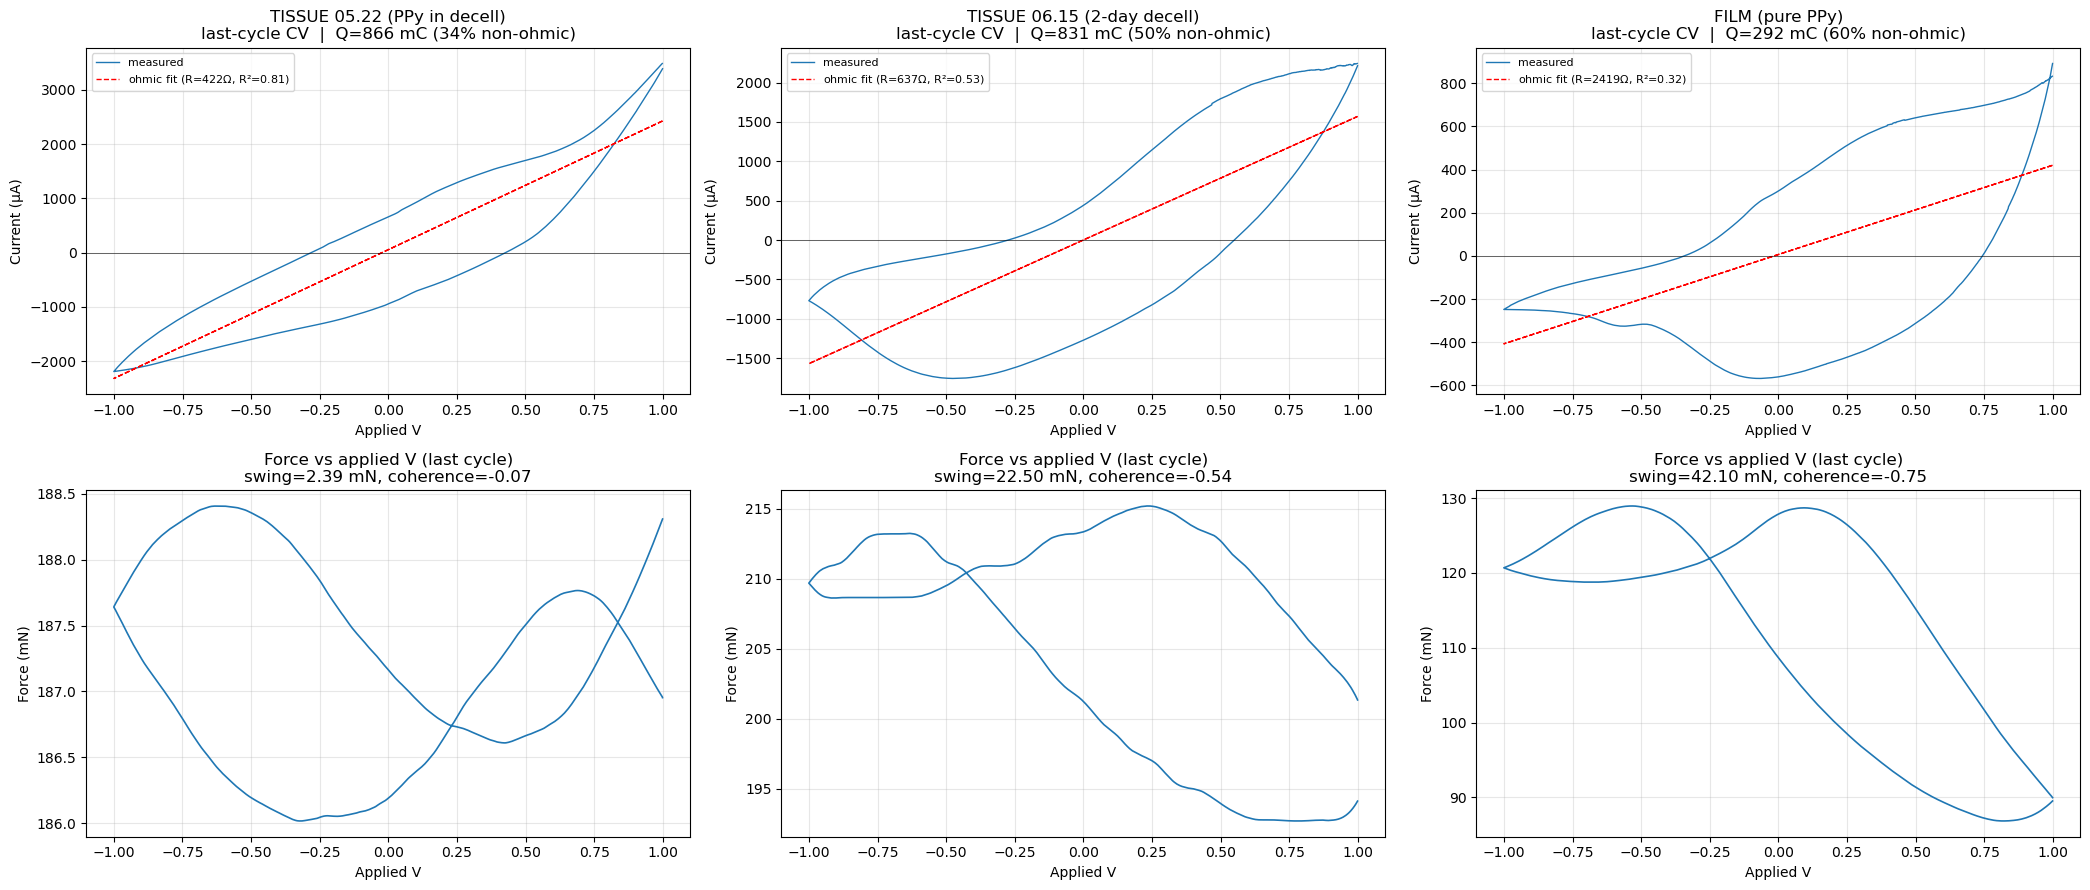

In [4]:
# ---- Visual: CV with ohmic backbone (top), force-vs-potential coherence (bottom) ----
ncols = len(res)
fig,ax=plt.subplots(2,ncols,figsize=(7*ncols,9),squeeze=False)
for col,(nm,r) in enumerate(res.items()):
    ax[0,col].plot(r['v'],r['i_uA'],lw=1.0,label='measured')
    ax[0,col].plot(r['v'],r['pred'],'r--',lw=1,label=f"ohmic fit (R={r['R_ohm']:.0f}$\\Omega$, R²={r['r2_ohmic']:.2f})")
    ax[0,col].axhline(0,color='k',lw=.4); ax[0,col].set_title(f'{nm}\nlast-cycle CV  |  Q={r["q_mean_mC"]:.0f} mC ({r["frac_nonohmic"]*100:.0f}% non-ohmic)')
    ax[0,col].set_xlabel('Applied V'); ax[0,col].set_ylabel('Current (µA)'); ax[0,col].legend(fontsize=8); ax[0,col].grid(alpha=.3)
    ax[1,col].plot(r['vapp'],r['ysm']*GAIN_MN_PER_V,lw=1.2)
    ax[1,col].set_title(f'Force vs applied V (last cycle)\nswing={r["force_pp_mN"]:.2f} mN, coherence={r["coherence_force_V"]:+.2f}')
    ax[1,col].set_xlabel('Applied V'); ax[1,col].set_ylabel('Force (mN)'); ax[1,col].grid(alpha=.3)
fig.tight_layout(); plt.show()

## Read-out

- **Access is NOT the limiter.** The tissue passes *more* total charge than the film (and ~4x the peak current) — it is not charge-starved.
- **But its charge is low-quality.** ~half of the tissue's charge is ohmic leakage through the wet conductive tissue (R~0.4 kΩ, ohmic R²~0.8), vs the film whose charge is ~84% genuine redox/capacitive (R~2.4 kΩ).
- **Per construct volume**, tissue charge density is ~18x lower — consistent with only a few-% PPy volume fraction diluted in tissue (a loading/percolation contribution).
- **The decisive metric:** the tissue's force swing is small *and electrochemically incoherent* (corr with applied V ~ −0.07 = drift, not actuation), while the film's force tracks the redox cycle tightly (corr ~ −0.75). Force-per-charge is ~30–50x worse for the tissue even after crediting only its non-ohmic charge.

**Diagnosis:** healthy/excess charge, ~zero coherent force -> the bottleneck is **downstream of charge injection (coupling + dilute loading)**, not electrical access. The PPy redox is happening but its strain is not being transduced into load-bearing force — most likely absorbed by the compliant tissue matrix and/or generated by a poorly-percolated PPy fraction in a 52x-thicker, diffusion-limited construct.

## Update — the new **06.15 2-day-decell tissue** is a much better actuator (FORCE)

Adding the 2026-06-15 run changes the story for the *new* construct (the 05.22 read-out above still stands for the old one):

- **Coherent, load-bearing force now exists.** Force–potential coherence jumped to **−0.54** (old tissue −0.07 ≈ drift; film −0.75). The force genuinely tracks the redox cycle — consistent with the square-wave step test.
- **Force swing ~9× the old tissue:** **22.5 mN / 20 kPa** (old 2.4 mN / 0.5 kPa; film 42 mN / 501 kPa). It now reaches ~half the film's *force*, though film still wins on *stress* because it's far thinner.
- **Efficiency gap closed ~10×:** force-per-charge **0.027 mN/mC**, only ~5× below film (old tissue was ~50× below).
- **Charge quality improved:** ~**50 %** non-ohmic (old 34 %), R ≈ 0.64 kΩ — less of the current is wasted as ohmic leakage.

**Why, most likely:** the new construct is far thinner (0.45 mm vs 1.467 mm) and differently prepped (10 % formalin, 2-day decell), so the PPy is better coupled to a less compliant, less diffusion-limited matrix. The earlier "downstream coupling/loading bottleneck" is substantially relieved here.
